In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

In [2]:
from models.plightning import  MainDataModule

dataset_dir = "../data/Sideview_Dec04_2024"
datamodule = MainDataModule(dataset_dir,
                            image_size=224,
                            load_depth=False,
                            train_batch_size=32, num_workers=1, process_leaf=False, preload=False, side_view=True)
datamodule.setup()

# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import cv2

test_dataloader = datamodule.test_dataloader(shuffle=False)
test_dataset = test_dataloader.dataset

# Plot the images
plt.figure(figsize=(10, 20))  # Adjust the figure size for vertical layout
n = 5
for i in range(n):
    image, _, vecs, _ = test_dataset[4*i]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    if 0:
        img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    else:
        img = np.array(image_rgb.cpu())
    
    
    # Split the 4-part image into 4 separate images
    img_size = img.shape[0] // 2
    img1 = img[:img_size, :img_size]
    img2 = img[:img_size, img_size:]
    img3 = img[img_size:, :img_size]
    img4 = img[img_size:, img_size:]
    
    # Combine the 4-part images into a single image
    combined_img = np.vstack((img1, img2,img3, img4))
    
    # Plot the combined image
    plt.subplot(1, n, i+1)
    plt.imshow(combined_img, vmax=255, vmin=0)
    plt.title(f"Image {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

/Users/lion397/codes_2024_work/Image2PlantArchitecture/.env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/lion397/codes_2024_work/Image2PlantArchitecture/.env/lib/python3.8/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Total 200 images and plant strings loaded
Total 40 images and plant strings loaded
Total 40 images and plant strings loaded


ValueError: not enough values to unpack (expected 4, got 3)

<Figure size 1000x2000 with 0 Axes>

Total 200 images and plant strings loaded
Total 40 images and plant strings loaded
Total 40 images and plant strings loaded


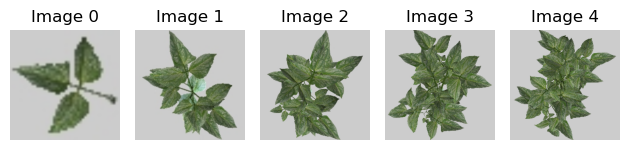

In [ ]:
dataset_dir = "../data/Sideview_Dec04_2024"
datamodule = MainDataModule(dataset_dir,
                            image_size=224,
                            load_depth=False,
                            train_batch_size=32, num_workers=1, process_leaf=True, preload=False, side_view=False)
datamodule.setup()
test_dataloader = datamodule.test_dataloader(shuffle=False)
test_dataset = test_dataloader.dataset
for i in range(n):
    image, _, vecs, _ = test_dataset[4*i]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    if 0:
        img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    else:
        img = np.array(image_rgb.cpu())
    
    # Plot the combined image
    plt.subplot(1, n, i+1)
    plt.imshow(img, vmax=255, vmin=0)
    plt.title(f"Image {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

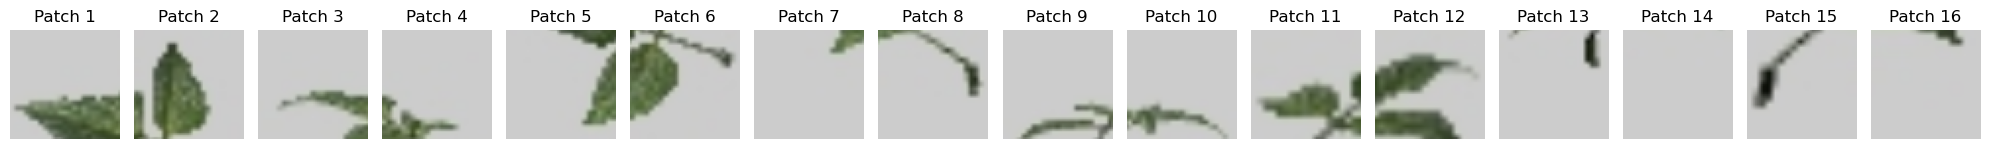

In [ ]:
image, _, vecs, _ = test_dataset[0]

# Assuming `image` is a PyTorch tensor with shape (C, H, W)
# Convert it to (H, W, C) for visualization
image = image.permute(1, 2, 0).cpu().numpy()

# Define the patch size (e.g., 16x16)
h, w, c = image.shape
patch_size = h // 4

# Ensure the image dimensions are divisible by the patch size
assert h % patch_size == 0 and w % patch_size == 0, "Image dimensions must be divisible by the patch size."

# Split the image into patches
patches = []
num_patches = h // patch_size
for i in range(0, h, patch_size):
    for j in range(0, w, patch_size):
        patch = image[i:i+patch_size, j:j+patch_size, :]
        patches.append(patch)

# Visualize the patches in a single row
plt.figure(figsize=(20, 5))
for idx, patch in enumerate(patches):
    plt.subplot(1, len(patches), idx + 1)
    plt.imshow(patch)
    plt.axis('off')
    plt.title(f"Patch {idx+1}")

plt.tight_layout()
plt.show()

In [5]:
import xml.etree.ElementTree as ET
from string_to_xml_to_vec import xml2vec, pretty_print_xml, linked_to_recursive
from plant_tokenizer import vec2token
# Load Test Data
xml_file = "GenerateDataset/build_release/paper_example_nested_auxbud.xml"
tree = ET.parse(xml_file)
root = tree.getroot()
root = linked_to_recursive(root)
plant_array_gt = []
for plant_instance in root:
    plant_instance_array = []
    xml2vec(plant_instance, plant_instance_array)
    plant_array_gt.append(plant_instance_array)

In [ ]:
# print(plant_array[0])
two_digit_codes = [f"{x[0]:1d}{x[1]}" for x in plant_array_gt[0]]
print(two_digit_codes)


['00', '01', '02', '03', '10', '11', '12', '13', '14', '15', '20', '21', '22', '23', '24', '25', '11', '12', '13', '14', '15', '11', '12', '13', '14', '15', '11', '12', '13', '14', '15', '11', '12', '13', '14', '15', '02', '03']


In [11]:
len(two_digit_codes)

38

In [ ]:
output=""
for line in plant_array_gt[0]:
    output += f"{line[0]}{line[1]},"
    for i, x in enumerate(line[2:]):
        #output += f"'{x}',"
        output += f"p{i},"
print(output)

00,p0,p1,p2,p3,p4,01,p0,p1,p2,p3,02,p0,p1,p2,p3,p4,03,p0,p1,p2,p3,10,p0,p1,p2,p3,p4,11,p0,p1,p2,p3,12,p0,p1,p2,p3,p4,13,p0,p1,p2,p3,14,p0,p1,p2,p3,15,p0,p1,p2,p3,20,p0,p1,p2,p3,p4,21,p0,p1,p2,p3,22,p0,p1,p2,p3,p4,23,p0,p1,p2,p3,24,p0,p1,p2,p3,25,p0,p1,p2,p3,11,p0,p1,p2,p3,12,p0,p1,p2,p3,p4,13,p0,p1,p2,p3,14,p0,p1,p2,p3,15,p0,p1,p2,p3,11,p0,p1,p2,p3,12,p0,p1,p2,p3,p4,13,p0,p1,p2,p3,14,p0,p1,p2,p3,15,p0,p1,p2,p3,11,p0,p1,p2,p3,12,p0,p1,p2,p3,p4,13,p0,p1,p2,p3,14,p0,p1,p2,p3,15,p0,p1,p2,p3,11,p0,p1,p2,p3,12,p0,p1,p2,p3,p4,13,p0,p1,p2,p3,14,p0,p1,p2,p3,15,p0,p1,p2,p3,02,p0,p1,p2,p3,p4,03,p0,p1,p2,p3,


In [6]:
from plant_tokenizer import vec2token
tokens = vec2token(plant_array_gt[0])
np.set_printoptions(suppress=True)
print(tokens.tolist())

[0, 35, 35, 79, 74, 72, 1, 46, 36, 35, 81, 2, 38, 36, 78, 30, 72, 3, 47, 73, 35, 33, 6, 35, 35, 35, 74, 73, 7, 45, 36, 73, 35, 8, 47, 35, 78, 30, 71, 9, 46, 35, 74, 33, 10, 47, 74, 35, 33, 11, 46, 73, 34, 33, 12, 76, 35, 35, 74, 73, 13, 40, 35, 35, 35, 14, 38, 35, 35, 30, 71, 15, 40, 35, 74, 33, 16, 40, 74, 35, 33, 17, 40, 73, 34, 33, 7, 45, 36, 35, 81, 8, 47, 35, 77, 30, 71, 9, 46, 35, 74, 33, 10, 47, 74, 35, 33, 11, 46, 73, 34, 33, 7, 45, 36, 34, 81, 8, 47, 35, 77, 30, 71, 9, 46, 35, 74, 33, 10, 47, 74, 35, 33, 11, 46, 73, 34, 33, 7, 45, 36, 35, 81, 8, 47, 35, 77, 30, 71, 9, 46, 35, 74, 33, 10, 47, 74, 35, 33, 11, 46, 73, 34, 33, 7, 40, 36, 74, 31, 8, 36, 35, 77, 30, 71, 9, 45, 35, 74, 33, 10, 45, 74, 35, 33, 11, 45, 73, 34, 33, 2, 38, 36, 78, 30, 72, 3, 47, 34, 35, 33]


In [26]:
output=""
for i, x in enumerate(tokens):
    output += f"{x},"
print(output)

0,35,35,79,74,72,1,46,36,35,81,2,38,36,78,30,72,3,47,73,35,33,6,35,35,35,74,73,7,45,36,73,35,8,47,35,78,30,71,9,46,35,74,33,10,47,74,35,33,11,46,73,34,33,12,76,35,35,74,73,13,40,35,35,35,14,38,35,35,30,71,15,40,35,74,33,16,40,74,35,33,17,40,73,34,33,7,45,36,35,81,8,47,35,77,30,71,9,46,35,74,33,10,47,74,35,33,11,46,73,34,33,7,45,36,34,81,8,47,35,77,30,71,9,46,35,74,33,10,47,74,35,33,11,46,73,34,33,7,45,36,35,81,8,47,35,77,30,71,9,46,35,74,33,10,47,74,35,33,11,46,73,34,33,7,40,36,74,31,8,36,35,77,30,71,9,45,35,74,33,10,45,74,35,33,11,45,73,34,33,2,38,36,78,30,72,3,47,34,35,33,


In [15]:
from plant_tokenizer import SOS_TOKEN, META_TOKEN, PAD_TOKEN, EOS_TOKEN
len(tokens)


print(EOS_TOKEN)

90


In [40]:
print((tokens[:,0]))

[ 0.  1.  2.  3.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.  7.  8.
  9. 10. 11.  7.  8.  9. 10. 11.  7.  8.  9. 10. 11.  7.  8.  9. 10. 11.
  2.  3.]


In [ ]:
int_tokens = [int(x) for x in tokens[:,0]]
print(int_tokens)
print(len(int_tokens))

[0, 1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 7, 8, 9, 10, 11, 7, 8, 9, 10, 11, 7, 8, 9, 10, 11, 7, 8, 9, 10, 11, 2, 3]
38


In [7]:
# Read XML file and tokenize it using transformers tokenizer
from transformers import AutoTokenizer

# Path to the XML file
xml_file = "GenerateDataset/build_release/paper_example_nested_auxbud.xml"

# Read the XML file as a text file
with open(xml_file, 'r', encoding='utf-8') as file:
    xml_content = file.read()

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the text content
tokens = tokenizer.tokenize(xml_content)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

# Print the tokens and token IDs
print("Tokens:", tokens)
print("Token IDs:", token_ids)

FileNotFoundError: [Errno 2] No such file or directory: 'GenerateDataset/build_release/paper_example_nested_auxbud.xml'

In [ ]:
from transformers import AutoTokenizer

# Path to the XML file
xml_file = "GenerateDataset/build_release/paper_example_nested_auxbud.xml"

# Read the XML file as a text file
with open(xml_file, 'r', encoding='utf-8') as file:
    xml_content = file.read()

# Initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the text content
tokens = tokenizer.tokenize(xml_content)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

# Decode the token IDs back to text
decoded_text = tokenizer.decode(token_ids)

# Remove unnecessary spaces
# decoded_text = decoded_text.replace(" ", "").replace(">", "> ").replace("<", " <").strip()


# Print the tokens and token IDs
print("Tokens:", tokens)
print("Token IDs:", token_ids)

# Print the original and decoded text for comparison
print("\nOriginal Text:\n", xml_content)
print("\nDecoded Text:\n", decoded_text)

# Compare the original and decoded text
if xml_content.strip() == decoded_text.strip():
    print("\nThe original and decoded text are identical.")
else:
    print("\nThe original and decoded text are different.")

Token indices sequence length is longer than the specified maximum sequence length for this model (3204 > 512). Running this sequence through the model will result in indexing errors


Tokens: ['<', '?', 'xml', 'version', '=', '"', '1', '.', '0', '"', 'encoding', '=', '"', 'ut', '##f', '-', '8', '"', '?', '>', '<', 'he', '##lio', '##s', '>', '<', 'plant', '_', 'instance', 'id', '=', '"', '0', '"', '>', '<', 'base', '_', 'position', '>', '0', '0', '0', '<', '/', 'base', '_', 'position', '>', '<', 'plant', '_', 'age', '>', '100', '<', '/', 'plant', '_', 'age', '>', '<', 'shoot', 'id', '=', '"', '0', '"', '>', '<', 'shoot', '_', 'type', '_', 'label', '>', 'un', '##ifolia', '##te', '<', '/', 'shoot', '_', 'type', '_', 'label', '>', '<', 'parent', '_', 'shoot', '_', 'id', '>', '-', '1', '<', '/', 'parent', '_', 'shoot', '_', 'id', '>', '<', 'parent', '_', 'node', '_', 'index', '>', '0', '<', '/', 'parent', '_', 'node', '_', 'index', '>', '<', 'parent', '_', 'pet', '##iol', '##e', '_', 'index', '>', '0', '<', '/', 'parent', '_', 'pet', '##iol', '##e', '_', 'index', '>', '<', 'base', '_', 'rotation', '>', '0', '0', '90', '<', '/', 'base', '_', 'rotation', '>', '<', 'ph', '#

In [ ]:
print("\nOriginal Text:\n", xml_content)


Original Text:
 <?xml version="1.0" encoding="UTF-8"?>
<helios>
	<plant_instance ID="0">
		<base_position> 0 0 0 </base_position>
		<plant_age> 100 </plant_age>
		<shoot ID="0">
			<shoot_type_label> unifoliate </shoot_type_label>
			<parent_shoot_ID> -1 </parent_shoot_ID>
			<parent_node_index> 0 </parent_node_index>
			<parent_petiole_index> 0 </parent_petiole_index>
			<base_rotation> 0 0 90 </base_rotation>
			<phytomer>
				<internode>
					<internode_length>0.0020</internode_length>
					<internode_radius>0.0001</internode_radius>
					<internode_pitch>0</internode_pitch>
					<internode_phyllotactic_angle>151.438</internode_phyllotactic_angle>
					<petiole>
						<petiole_length>0.00026</petiole_length>
						<petiole_radius>0.000104</petiole_radius>
						<petiole_pitch>73.0784</petiole_pitch>
						<petiole_curvature>-137.6</petiole_curvature>
						<leaflet_scale>1</leaflet_scale>
						<leaf>
							<leaf_scale>0.0026</leaf_scale>
							<leaf_pitch>4.02381</leaf_pitch>
		

In [8]:
# 언제부터 틀리나?
import xml.etree.ElementTree as ET
from string_to_xml_to_vec import xml2vec, pretty_print_xml, linked_to_recursive
from plant_tokenizer import vec2token
import numpy as np

# Load Test Data
xml_file = "for_paper/plant_4_gt.xml"
tree = ET.parse(xml_file)
root = tree.getroot()
root = linked_to_recursive(root)
plant_array_gt = []
for plant_instance in root:
    plant_instance_array = []
    xml2vec(plant_instance, plant_instance_array)
    plant_array_gt.append(plant_instance_array)

tokens_gt = vec2token(plant_array_gt[0])
np.set_printoptions(suppress=True)
print(tokens_gt.tolist())

xml_file = "for_paper/plant_4_generate.xml"
tree = ET.parse(xml_file)
root = tree.getroot()
root = linked_to_recursive(root)
plant_array_gen = []
for plant_instance in root:
    plant_instance_array = []
    xml2vec(plant_instance, plant_instance_array)
    plant_array_gen.append(plant_instance_array)

tokens_gen = vec2token(plant_array_gen[0])
np.set_printoptions(suppress=True)
print(tokens_gen.tolist())

print(tokens_gt[:,0])
print(f"len:{len(tokens_gt[:,0])}")

print(tokens_gen[:,0])
print(f"len:{len(tokens_gen[:,0])}")

[[0.0, 8.93171, 26.603, 240.159, 12.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.03, 0.00198017, 0.0, 177.506, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0004, 72.2065, -90.1598, 1.0, 0.0, 0.0, 0.0, 0.0], [3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, -5.33152, 0.0, -15.0], [6.0, 0.0, 0.0, 90.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [7.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.00184072, 20.0, 183.517, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00644925, 0.000137135, 59.7494, -191.203, 0.9, 0.0, 0.0, 0.0, 0.0], [9.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00665276, 3.09879, 10.0, -15.0], [10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00739196, -11.6248, 0.0, -15.0], [11.0, 0.0,

list1[56] != list2[56]
56


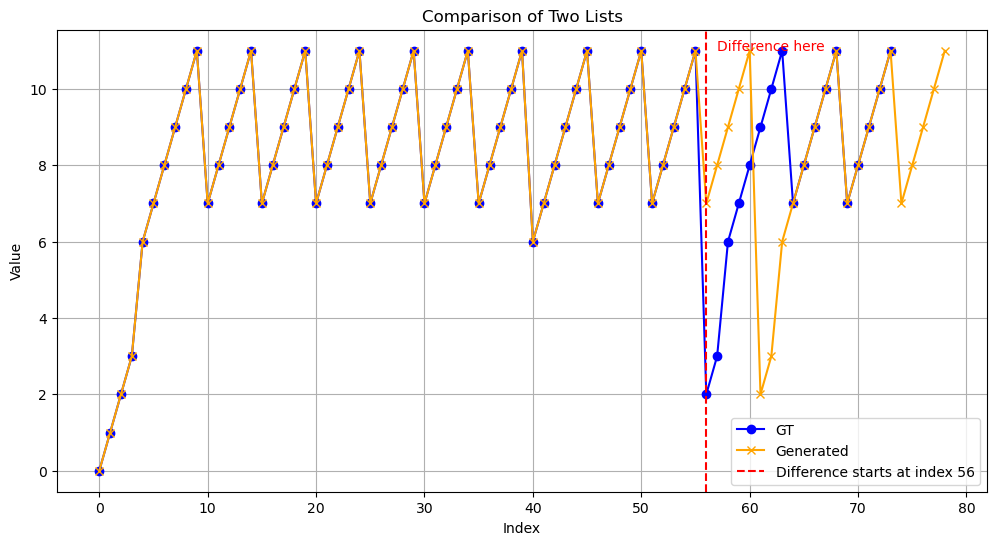

In [9]:
import matplotlib.pyplot as plt
# 차이 발생 인덱스 찾기
list1 = tokens_gt[:,0]
list2 = tokens_gen[:,0]


def find_where_is_wrong(list1, list2):
    min_len = min(len(list1), len(list2))
    for i in range(min_len):
        if list1[i] != list2[i]:
            print(f"list1[{i}] != list2[{i}]")
            break
        else:
            pass


    return i

diff_index = find_where_is_wrong(list1,list2)
print(diff_index)

# 그래프 그리기
plt.figure(figsize=(12, 6))

# 리스트 1
plt.plot(list1, label='GT', color='blue', marker='o')

# 리스트 2
plt.plot(list2, label='Generated', color='orange', marker='x')

# 차이 발생 인덱스 표시
plt.axvline(x=diff_index, color='red', linestyle='--', label=f'Difference starts at index {diff_index}')
plt.text(diff_index + 1, max(np.max(list1), np.max(list2)), f'Difference here', color='red')

# 제목 및 라벨 설정
plt.title('Comparison of Two Lists')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid()

# 그래프 나타내기
plt.show()

In [10]:
import subprocess

# Function to re-render a single XML file
def re_render_xml(output_path, filename, rotation=True):
    program_path = "../src/GenerateDataset/build"
    image_name = filename.split("/")[-1].split(".")[0]
    os.environ["DISPLAY"] = ":12.0"
    #os.environ["DISPLAY"] = ":1.0"
    # Generate image 
    # Construct the command
    command = ""
    command += f"cd {program_path} && ./main " 
    command += f"-h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    return result

In [11]:
try:
    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name_generate_beam))
    img_generate_beam, _ = load_sideview_images(temp_folder, plant_xml_file_name_generate_beam.replace("xml","jpeg"), model.image_size, True)
except ValueError as e:
    print(f"Error loading image: {e}")
    img_generate_beam = np.zeros((image_size, image_size, 3), dtype=np.uint8)
    cv2.putText(img_generate_beam, 'Error Generating', (10, image_size // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

image_vis = image[0].permute(1, 2, 0).cpu()
image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

NameError: name 'temp_folder' is not defined

In [2]:
import os
import numpy as np
from tqdm import tqdm
from string_to_xml_to_vec import xml2vec, linked_to_recursive
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

def process_xml_files(dataset_dir, file_suffix):
    xml_files = [f for f in os.listdir(dataset_dir) if f.endswith(file_suffix)]
    xml_files.sort()
    plant_array = []
    for xml_file in tqdm(xml_files):
        xml_file = os.path.join(dataset_dir, xml_file)
        tree = ET.parse(xml_file)
        root = tree.getroot()
        root = linked_to_recursive(root)
        for plant_instance in root:
            plant_instance_array = []
            xml2vec(plant_instance, plant_instance_array)
            plant_array.append(plant_instance_array)
    return plant_array

def extract_params(plant_array):
    all_shoot_params = []
    all_internode_params = []
    all_petiole_params = []
    all_leaf_params = []
    for token in plant_array:
        for vec in token:
            organ_type = vec[1]
            if organ_type == 0:
                all_shoot_params.append(vec[2:])
            elif organ_type == 1:
                all_internode_params.append(vec[2:])
            elif organ_type == 2:
                all_petiole_params.append(vec[2:])
            elif organ_type == 3:
                all_leaf_params.append(vec[2:])
    return (np.array(all_shoot_params), np.array(all_internode_params), np.array(all_petiole_params), np.array(all_leaf_params))

In [ ]:
# GT 데이터셋 처리
gt_dataset_dir = "output/20250124_SideView_224_40Days"
gt_plant_array = process_xml_files(gt_dataset_dir, '_gt.xml')
gt_shoot_params, gt_internode_params, gt_petiole_params, gt_leaf_params = extract_params(gt_plant_array)

# EST 데이터셋 처리
est_dataset_dir = gt_dataset_dir
est_plant_array = process_xml_files(est_dataset_dir, '_est.xml')
est_shoot_params, est_internode_params, est_petiole_params, est_leaf_params = extract_params(est_plant_array)

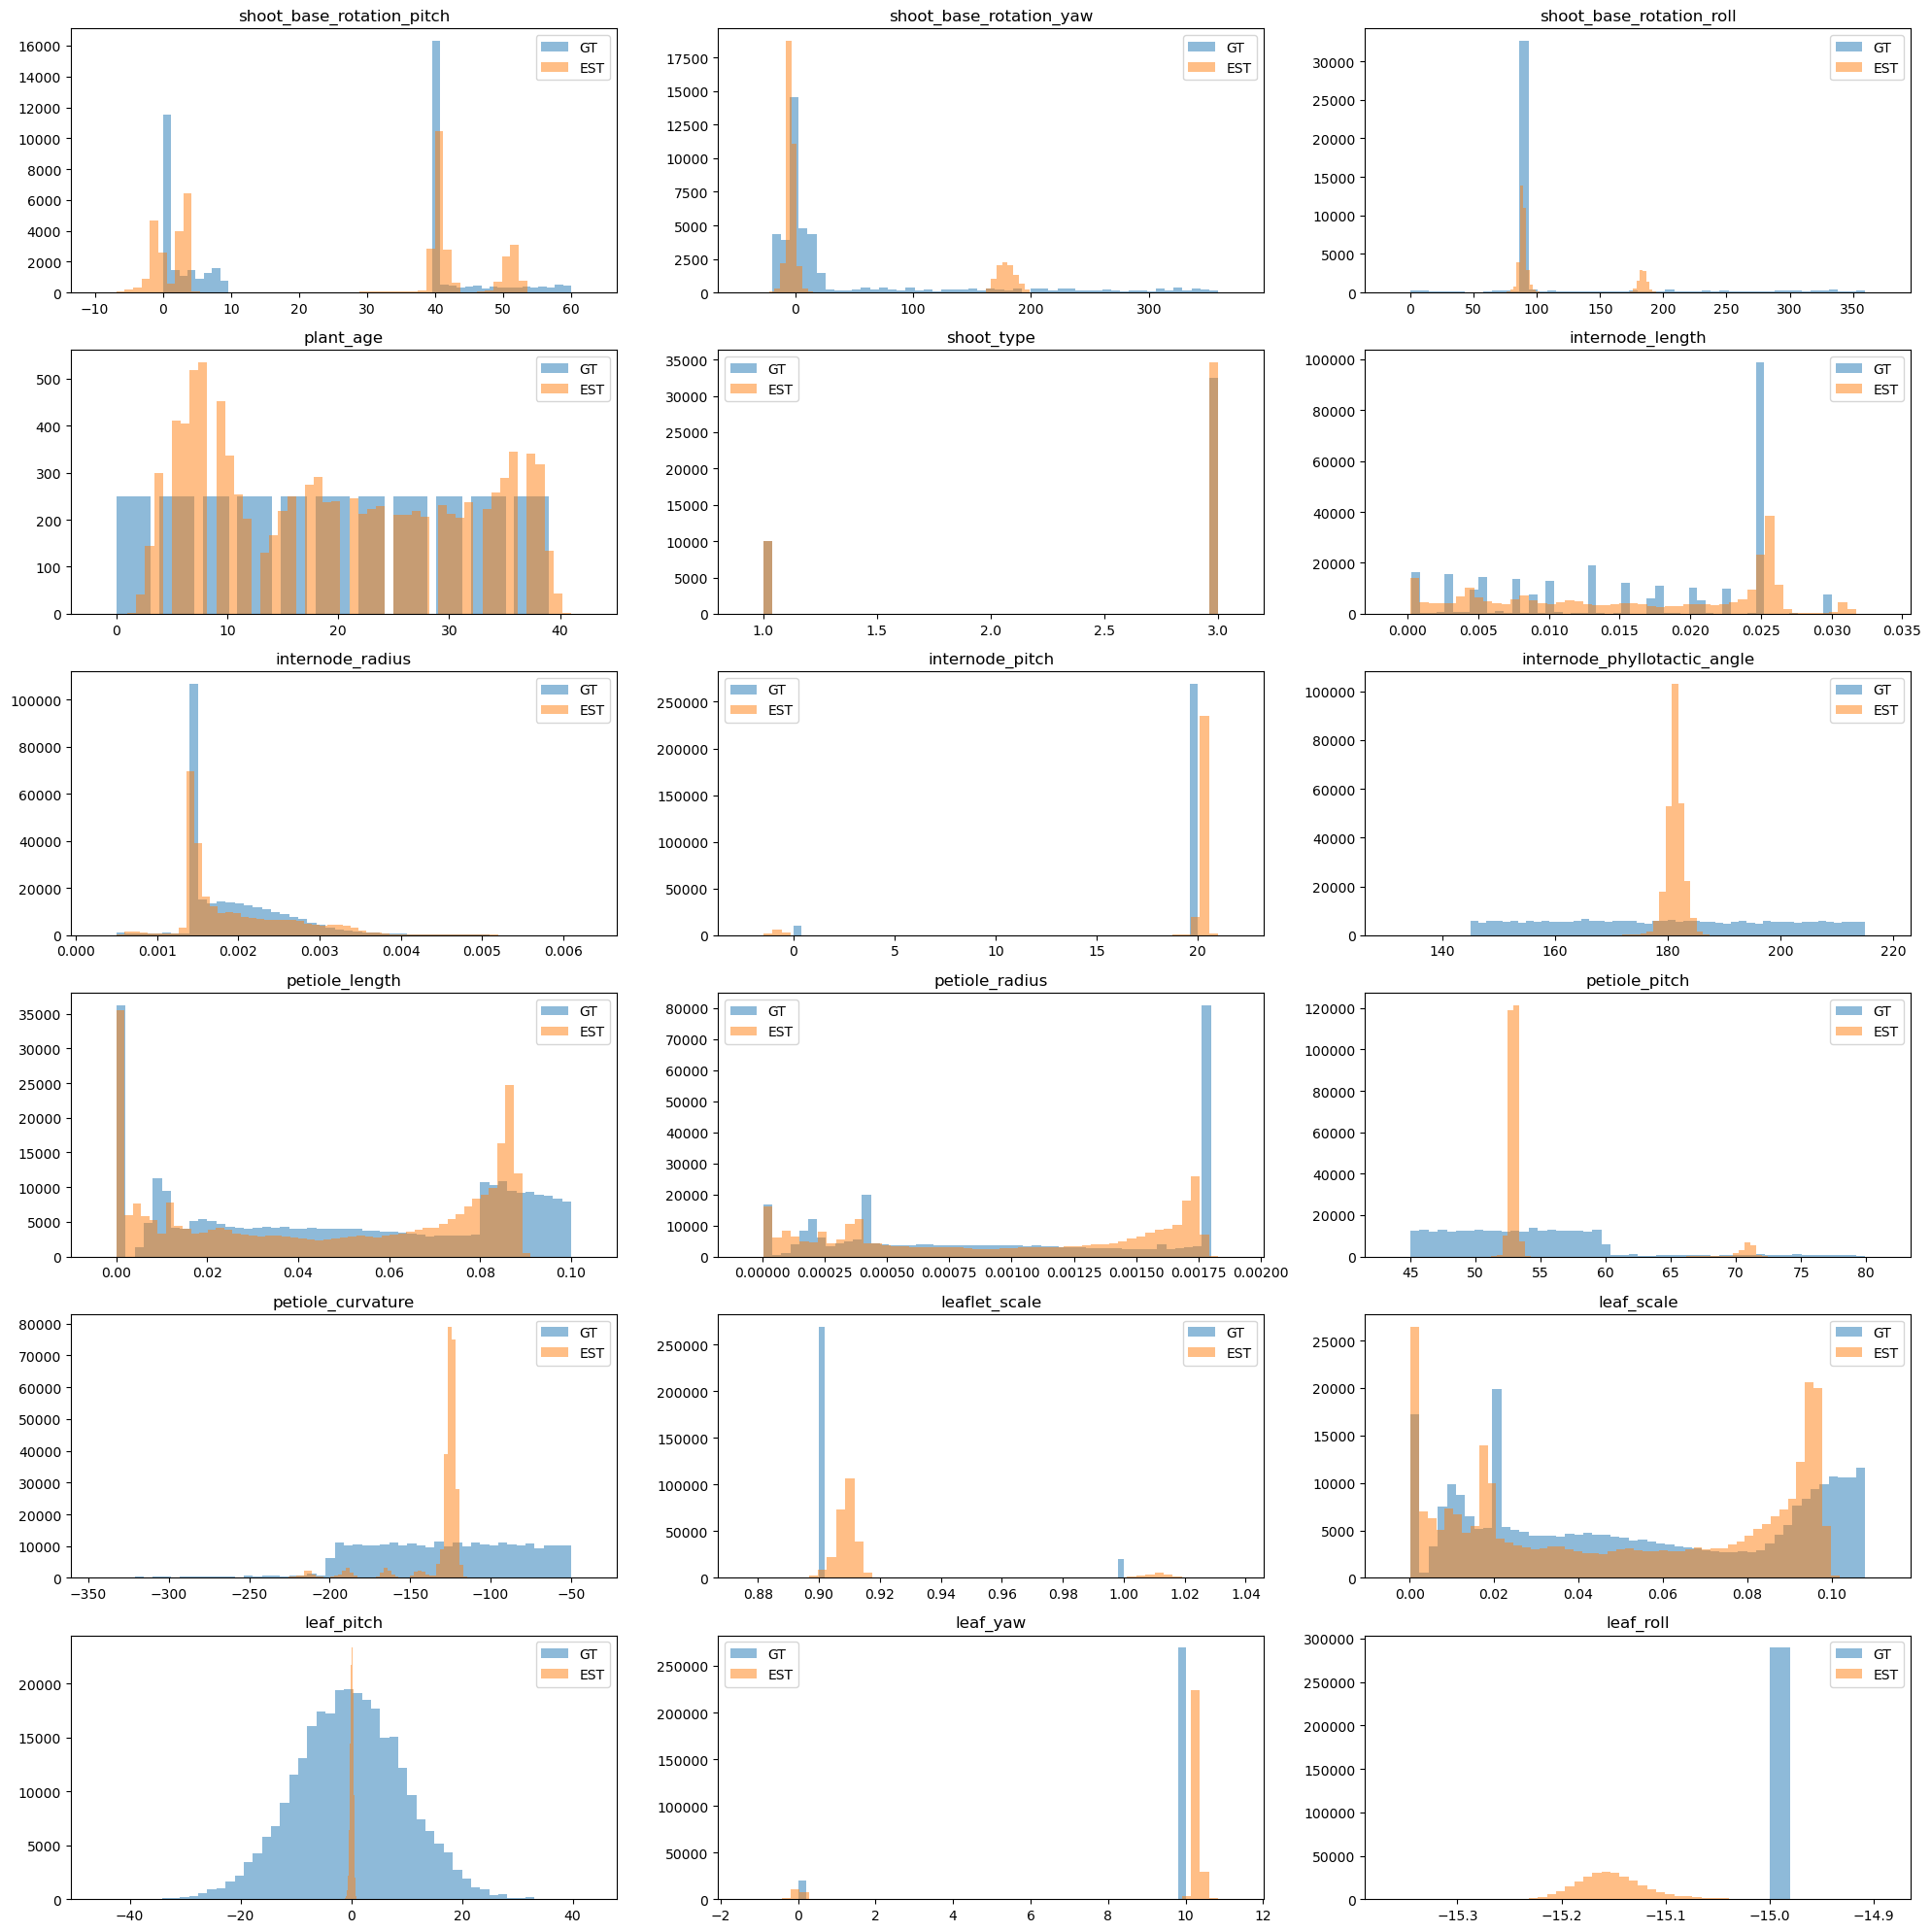

In [13]:
# Plant age
gt_plant_age = np.array([x[0][5] for x in gt_plant_array])
est_plant_age = np.array([x[0][5] for x in est_plant_array])

# 파라미터 추출
params = [
    (gt_shoot_params[:, 0], est_shoot_params[:, 0], "shoot_base_rotation_pitch"),
    (gt_shoot_params[:, 1], est_shoot_params[:, 1], "shoot_base_rotation_yaw"),
    (gt_shoot_params[:, 2], est_shoot_params[:, 2], "shoot_base_rotation_roll"),
    (gt_plant_age, est_plant_age, "plant_age"),
    (gt_shoot_params[:, 4], est_shoot_params[:, 4], "shoot_type"),
    (gt_internode_params[:, 0], est_internode_params[:, 0], "internode_length"),
    (gt_internode_params[:, 1], est_internode_params[:, 1], "internode_radius"),
    (gt_internode_params[:, 2], est_internode_params[:, 2], "internode_pitch"),
    (gt_internode_params[:, 3], est_internode_params[:, 3], "internode_phyllotactic_angle"),
    (gt_petiole_params[:, 0], est_petiole_params[:, 0], "petiole_length"),
    (gt_petiole_params[:, 1], est_petiole_params[:, 1], "petiole_radius"),
    (gt_petiole_params[:, 2], est_petiole_params[:, 2], "petiole_pitch"),
    (gt_petiole_params[:, 3], est_petiole_params[:, 3], "petiole_curvature"),
    (gt_petiole_params[:, 4], est_petiole_params[:, 4], "leaflet_scale"),
    (gt_leaf_params[:, 0], est_leaf_params[:, 0], "leaf_scale"),
    (gt_leaf_params[:, 1], est_leaf_params[:, 1], "leaf_pitch"),
    (gt_leaf_params[:, 2], est_leaf_params[:, 2], "leaf_yaw"),
    (gt_leaf_params[:, 3], est_leaf_params[:, 3], "leaf_roll")
]

# 그래프 그리기
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 20))
axes = axes.flatten()

for ax, (gt_param, est_param, title) in zip(axes, params):
    ax.hist(gt_param, bins=50, alpha=0.5, label='GT')
    ax.hist(est_param, bins=50, alpha=0.5, label='EST')

    # Add margin to the X-axis
    x_min = min(gt_param.min(), est_param.min())
    x_max = max(gt_param.max(), est_param.max())
    margin = (x_max - x_min) * 0.10  # 10% margin
    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Plant Age')

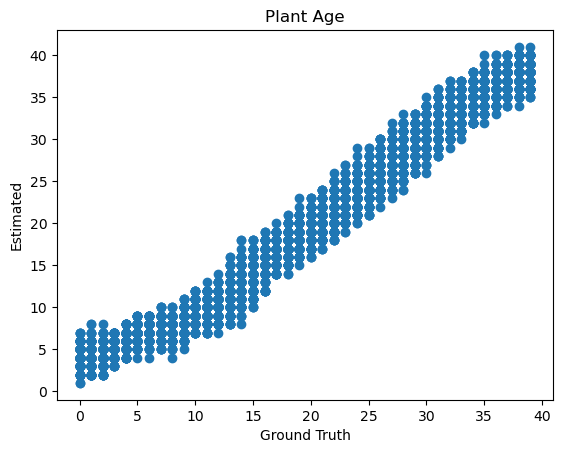

In [ ]:
gt_plant_age = np.array([x[0][5] for x in gt_plant_array])
est_plant_age = np.array([x[0][5] for x in est_plant_array])

plt.scatter(gt_plant_age, est_plant_age)
plt.xlabel("Ground Truth (Days)")
plt.ylabel("Estimated (Days)")
plt.title("Plant Age")

Text(0, 0.5, 'Estimated')

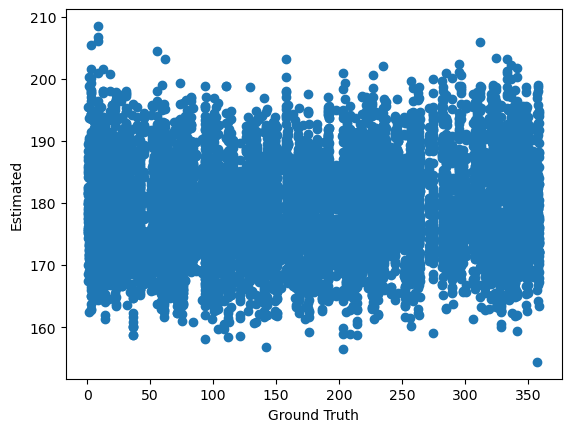

In [15]:
gt_base_pitch = np.array([x[0][3] for x in gt_plant_array])
est_base_pitch = np.array([x[0][3] for x in est_plant_array])

plt.scatter(gt_base_pitch, est_base_pitch)
plt.xlabel("Ground Truth")
plt.ylabel("Estimated")

# Investigate Depth Anything v2

In [2]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
depth_est_model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")


In [17]:
from torchviz import make_dot
import torch

# Dummy input for the model
dummy_input = torch.randn(1, 3, 224, 224)

# Forward pass
output = depth_est_model(dummy_input)

print(output)
# Check if output is a tensor, if not convert it to a tensor
if isinstance(output, dict):
    output = output.predicted_depth  # Adjust this key based on the actual output structure

# Visualize the model
make_dot(output, params=dict(depth_est_model.named_parameters())).render("depth_est_model_structure", format="png")

DepthEstimatorOutput(loss=None, predicted_depth=tensor([[[2.3309, 2.3179, 2.3254,  ..., 2.2937, 2.3337, 1.9512],
         [2.3324, 2.3089, 2.2945,  ..., 2.3235, 2.2856, 2.2111],
         [2.3130, 2.3124, 2.3189,  ..., 2.3438, 2.3237, 2.3062],
         ...,
         [2.7694, 2.7740, 2.7798,  ..., 2.6842, 2.6635, 2.6631],
         [2.7858, 2.7828, 2.7841,  ..., 2.6845, 2.6823, 2.6822],
         [2.7384, 2.7774, 2.7548,  ..., 2.6591, 2.6848, 2.7120]]],
       grad_fn=<SqueezeBackward1>), hidden_states=None, attentions=None)


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.838138 to fit


'depth_est_model_structure.png'

In [35]:
depth_est_model.backbone.encoder.layer[-1]

Dinov2Layer(
  (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (attention): Dinov2Attention(
    (attention): Dinov2SelfAttention(
      (query): Linear(in_features=384, out_features=384, bias=True)
      (key): Linear(in_features=384, out_features=384, bias=True)
      (value): Linear(in_features=384, out_features=384, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): Dinov2SelfOutput(
      (dense): Linear(in_features=384, out_features=384, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (layer_scale1): Dinov2LayerScale()
  (drop_path): Identity()
  (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (mlp): Dinov2MLP(
    (fc1): Linear(in_features=384, out_features=1536, bias=True)
    (activation): GELUActivation()
    (fc2): Linear(in_features=1536, out_features=384, bias=True)
  )
  (layer_scale2): Dinov2LayerScale()
)

In [ ]:
import torch.onnx
# Export the model to ONNX
onnx_path = "depth_est_model.onnx"
torch.onnx.export(depth_est_model, dummy_input, onnx_path, opset_version=11)